<a href="https://colab.research.google.com/github/zccarver001-gif/WiDS-University-Datathon-2026/blob/main/WiDS-University-Datathon2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
# Random Forest for Evacuation

import pandas as pd
import numpy as np
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Import the data
event_df = pd.read_csv("evac_zone_status_geo_event_map.csv")
zones_df = pd.read_csv("evac_zones_gis_evaczone.csv")
zonechanges_df = pd.read_csv("evac_zones_gis_evaczonechangelog.csv")

# Preview data
print(event_df.head())
print(zones_df.head())
print(zonechanges_df.head())

                 date_created                                    uid_v2  \
0  2023-10-25 11:28:15.254517    sierra-CA_US-SIE-E062-778dddb3cad71e9f   
1  2023-10-25 11:28:15.254550    sierra-CA_US-SIE-E063-f59f54f1edf93b15   
2  2023-10-25 11:28:15.254565    sierra-CA_US-SIE-E060-64dbd0e15d47d9bb   
3  2023-11-02 21:52:49.867450  butte-CA_US-BUT-CNE-311-474a247dbeb74ebf   
4  2024-05-02 20:53:00.964490       kern-CA_US-KRN-289-7cd3f4bbc76a4b2d   

   geo_event_id  
0         14107  
1         14107  
2         14107  
3         14505  
4         18785  
   id                   date_created                  date_modified  \
0   1  2025-04-10 13:22:22.896704+00  2025-08-19 01:58:01.009206+00   
1   2  2025-04-10 13:22:22.896921+00   2025-08-19 01:58:01.00957+00   
2   3  2025-04-10 13:22:22.897002+00  2025-08-19 01:58:01.009741+00   
3   4  2025-04-10 13:22:22.897075+00  2025-08-19 01:58:01.009867+00   
4   5  2025-04-10 13:22:22.897156+00  2025-08-19 01:58:01.010002+00   

              

In [42]:
# --------------------------------------------
# Inspect ALL datasets
# --------------------------------------------

print("\nEVENT DF COLUMNS:")
print(event_df.columns.tolist())

print("\nZONES DF COLUMNS:")
print(zones_df.columns.tolist())

print("\nZONE CHANGES DF COLUMNS:")
print(zonechanges_df.columns.tolist())

# Preview rows
print("\nZONES DF HEAD:")
print(zones_df.head())

print("\nZONE CHANGES DF HEAD:")
print(zonechanges_df.head())


EVENT DF COLUMNS:
['date_created', 'uid_v2', 'geo_event_id']

ZONES DF COLUMNS:
['id', 'date_created', 'date_modified', 'uid_v2', 'is_active', 'display_name', 'region_id', 'source_attribution', 'dataset_name', 'source_extra_data', 'geom', 'status', 'geom_label', 'is_pending_review', 'pending_updates', 'external_status']

ZONE CHANGES DF COLUMNS:
['id', 'date_created', 'changes', 'evac_zone_id']

ZONES DF HEAD:
   id                   date_created                  date_modified  \
0   1  2025-04-10 13:22:22.896704+00  2025-08-19 01:58:01.009206+00   
1   2  2025-04-10 13:22:22.896921+00   2025-08-19 01:58:01.00957+00   
2   3  2025-04-10 13:22:22.897002+00  2025-08-19 01:58:01.009741+00   
3   4  2025-04-10 13:22:22.897075+00  2025-08-19 01:58:01.009867+00   
4   5  2025-04-10 13:22:22.897156+00  2025-08-19 01:58:01.010002+00   

                                  uid_v2  is_active display_name  region_id  \
0  boulder-CO_US-BO-030-cc87104888faec63       True       BO-030        664   


In [43]:
# --------------------------------------------
# Basic Cleaning
# --------------------------------------------

# Clean zones_df
zones_df = zones_df.drop_duplicates()
zones_df['is_active'] = zones_df['is_active'].astype(str).str.strip().str.lower()
zones_df['is_pending_review'] = zones_df['is_pending_review'].astype(str).str.strip().str.lower()
zones_df['status'] = zones_df['status'].fillna('none')
zones_df['external_status'] = zones_df['external_status'].fillna('Unknown')

# Clean event_df
event_df = event_df.drop_duplicates()
event_df['date_created'] = pd.to_datetime(event_df['date_created'], utc=True, errors='coerce')

# Clean zonechanges_df
zonechanges_df = zonechanges_df.drop_duplicates()
zonechanges_df['date_created'] = pd.to_datetime(
    zonechanges_df['date_created'], utc=True, errors='coerce'
)

# Check results
print("Unique statuses:", zones_df['status'].unique())
print("\nNull counts in zones_df:")
print(zones_df.isnull().sum())

Unique statuses: ['none' 'advisories' 'orders' 'warnings']

Null counts in zones_df:
id                        0
date_created              0
date_modified             0
uid_v2                    0
is_active                 0
display_name              6
region_id                 0
source_attribution        0
dataset_name              0
source_extra_data         0
geom                      0
status                    0
geom_label                0
is_pending_review         0
pending_updates       37458
external_status           0
dtype: int64


In [44]:
# --------------------------------------------
# Merge All Three CSV Files
# --------------------------------------------

# Reset zones_df to the original to avoid duplicate column errors on re-run
zones_df = pd.read_csv("evac_zones_gis_evaczone.csv")
zones_df['is_active'] = zones_df['is_active'].astype(str).str.strip().str.lower()
zones_df['is_pending_review'] = zones_df['is_pending_review'].astype(str).str.strip().str.lower()
zones_df['status'] = zones_df['status'].fillna('none')
zones_df['external_status'] = zones_df['external_status'].fillna('Unknown')

# Summarize zonechanges_df down to one row per zone
changelog_summary = zonechanges_df.groupby('evac_zone_id').agg(
    total_changes = ('id', 'count'),
    first_change = ('date_created', 'min'),
    last_change_date = ('date_created', 'max'),
).reset_index()

zones_df = zones_df.merge(
    changelog_summary,
    left_on='id',
    right_on='evac_zone_id',
    how='left'
)

# Summarize event_df down to one row per zone
event_summary = event_df.groupby('uid_v2').agg(
    total_events = ('geo_event_id', 'count'),
    unique_events = ('geo_event_id', 'nunique'),
    first_event_date = ('date_created', 'min'),
    last_event_date = ('date_created', 'max'),
).reset_index()

zones_df = zones_df.merge(
    event_summary,
    on='uid_v2',
    how='left'
)

# Fill nulls for zones with no changelog or event entries
zones_df['total_changes'] = zones_df['total_changes'].fillna(0)
zones_df['total_events'] = zones_df['total_events'].fillna(0)
zones_df['unique_events'] = zones_df['unique_events'].fillna(0)

print("Merged dataframe shape:", zones_df.shape)
print("\nColumns after merge:")
print(zones_df.columns.tolist())

# --------------------------------------------
# Feature Engineering
# --------------------------------------------

# Days since the zone was last changed
ref_date = pd.Timestamp('2025-09-06', tz='UTC')
zones_df['days_since_change'] = (
    ref_date - pd.to_datetime(zones_df['last_change_date'], utc=True, errors='coerce')
).dt.days.fillna(999)

# Flag which zones had a status, geometry, or active change
def parse_change_keys(changes_str):
    try:
        d = json.loads(changes_str)
        return list(d.keys())
    except Exception:
        return []

zonechanges_df['change_keys'] = zonechanges_df['changes'].apply(parse_change_keys)

for field in ['status', 'geom', 'is_active']:
    flagged = (
        zonechanges_df[zonechanges_df['change_keys'].apply(lambda k: field in k)]
        ['evac_zone_id']
        .unique()
    )
    zones_df[f'had_{field}_change'] = zones_df['id'].isin(flagged).astype(int)

# How many times each zone had a status change
status_changes = zonechanges_df[zonechanges_df['change_keys'].apply(lambda k: 'status' in k)]
status_change_counts = (
    status_changes
    .groupby('evac_zone_id')
    .size()
    .reset_index(name='n_status_changes')
)
zones_df = zones_df.merge(
    status_change_counts,
    left_on='id',
    right_on='evac_zone_id',
    how='left'
)
zones_df['n_status_changes'] = zones_df['n_status_changes'].fillna(0)

# Pull coordinates from geom_label
def extract_coords(label):
    nums = re.findall(r'[-\d.]+', str(label))
    if len(nums) >= 2:
        return float(nums[0]), float(nums[1])
    return 0.0, 0.0

zones_df[['centroid_lon', 'centroid_lat']] = zones_df['geom_label'].apply(
    lambda x: pd.Series(extract_coords(x))
)

# Encode categorical columns as numbers
le = LabelEncoder()
zones_df['source_encoded'] = le.fit_transform(zones_df['source_attribution'].fillna('Unknown'))
zones_df['dataset_encoded'] = le.fit_transform(zones_df['dataset_name'].fillna('Unknown'))
zones_df['is_active_int'] = (zones_df['is_active'] == 'true').astype(int)
zones_df['pending_int'] = (zones_df['is_pending_review'] == 'true').astype(int)

# --------------------------------------------
# Early Warning Features
# --------------------------------------------

# Flag zones that escalated from warning to order in their changelog
def had_prior_warning(changes_str):
    try:
        d = json.loads(changes_str)
        if 'status' in d:
            old_status, new_status = d['status'][0], d['status'][1]
            if old_status == 'warnings' and new_status == 'orders':
                return True
    except Exception:
        pass
    return False

warning_to_order = zonechanges_df[zonechanges_df['changes'].apply(had_prior_warning)]
warning_escalators = warning_to_order['evac_zone_id'].unique()
zones_df['escalated_from_warning'] = zones_df['id'].isin(warning_escalators).astype(int)

# Flag zones currently sitting at warnings (prime candidates to watch)
zones_df['currently_warning'] = (zones_df['status'] == 'warnings').astype(int)

# --------------------------------------------
# Define feature_cols after ALL features are built
# --------------------------------------------

# Use total_changes and total_events from the merge
# instead of the old n_changes and n_events
feature_cols = [
    'is_active_int',
    'pending_int',
    'source_encoded',
    'dataset_encoded',
    'region_id',
    'total_changes',         # from merge — replaces n_changes
    'days_since_change',
    'had_geom_change',
    'had_is_active_change',
    'had_status_change',
    'n_status_changes',
    'total_events',          # from merge — replaces n_events
    'unique_events',         # new — how many distinct events hit this zone
    'centroid_lon',
    'centroid_lat',
    'escalated_from_warning',
]

print("\nFeature engineering done.")
print("Final zones_df shape:", zones_df.shape)
print("Zones that escalated from warning to order:", warning_escalators.shape[0])
print("Zones currently at warning:", zones_df['currently_warning'].sum())

# Save the merged file
zones_df.to_csv("merged_evac_data.csv", index=False)
print("\nSaved merged data to merged_evac_data.csv")

Merged dataframe shape: (37458, 24)

Columns after merge:
['id', 'date_created', 'date_modified', 'uid_v2', 'is_active', 'display_name', 'region_id', 'source_attribution', 'dataset_name', 'source_extra_data', 'geom', 'status', 'geom_label', 'is_pending_review', 'pending_updates', 'external_status', 'evac_zone_id', 'total_changes', 'first_change', 'last_change_date', 'total_events', 'unique_events', 'first_event_date', 'last_event_date']

Feature engineering done.
Final zones_df shape: (37458, 38)
Zones that escalated from warning to order: 167
Zones currently at warning: 53

Saved merged data to merged_evac_data.csv


In [49]:
# ---------------------------------
# Create Target Variable
# ---------------------------------

# Inspect unique statuses first
print(zones_df["status"].unique())

# Convert evacuation orders into binary labels
zones_df["target"] = (zones_df["status"] == "orders").astype(int)

print("\nTARGET COUNTS:")
print(zones_df["target"].value_counts())

['none' 'advisories' 'orders' 'warnings']

TARGET COUNTS:
target
0    37431
1       27
Name: count, dtype: int64


In [52]:
# --------------------------------------------
# Select Features & Split Data
# --------------------------------------------

# status and external_status are removed — they directly encode the target
# and would not be available at prediction time in a real early-warning system
feature_cols = [
    'is_active_int',
    'pending_int',
    'source_encoded',
    'dataset_encoded',
    'region_id',
    'total_changes',
    'days_since_change',
    'had_status_change',
    'had_geom_change',
    'had_is_active_change',
    'n_status_changes',
    'total_events',
    'centroid_lon',
    'centroid_lat',
]

X = zones_df[feature_cols].fillna(0)
y = zones_df["target"]

# Stratify keeps the same class ratio in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print("\nTrain target counts:")
print(y_train.value_counts())

Train size: 29966
Test size:  7492

Train target counts:
target
0    29944
1       22
Name: count, dtype: int64


In [53]:
# --------------------------------------------
# Handle Class Imbalance with SMOTE
# --------------------------------------------

# SMOTE creates synthetic minority samples so the model sees more "order" examples
# Only apply to training data, never to test data
sm = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print("After SMOTE:")
print(pd.Series(y_train_sm).value_counts())

After SMOTE:
target
0    29944
1    29944
Name: count, dtype: int64


In [54]:
# --------------------------------------------
# Train the Random Forest
# --------------------------------------------

clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

clf.fit(X_train_sm, y_train_sm)

print("Training complete.")

Training complete.


=== Classification Report ===
              precision    recall  f1-score   support

    No Order       1.00      1.00      1.00      7487
       Order       0.50      0.20      0.29         5

    accuracy                           1.00      7492
   macro avg       0.75      0.60      0.64      7492
weighted avg       1.00      1.00      1.00      7492

ROC-AUC Score: 0.9982


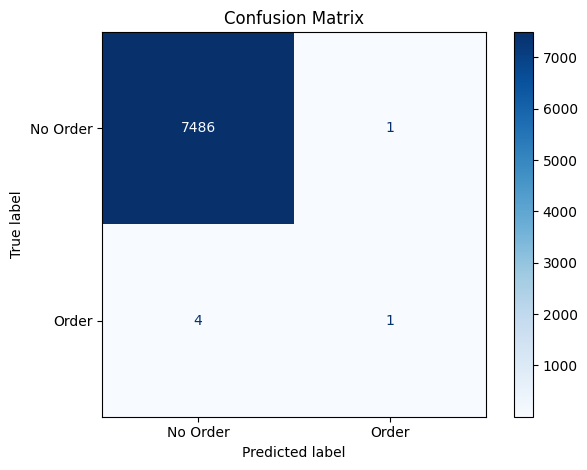

In [55]:
# --------------------------------------------
# Evaluate the Model
# --------------------------------------------

y_pred = clf.predict(X_test)
y_pred_prob = clf.predict_proba(X_test)[:, 1]

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['No Order', 'Order']))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Order', 'Order'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

/tmp/ipykernel_6059/3330029891.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')


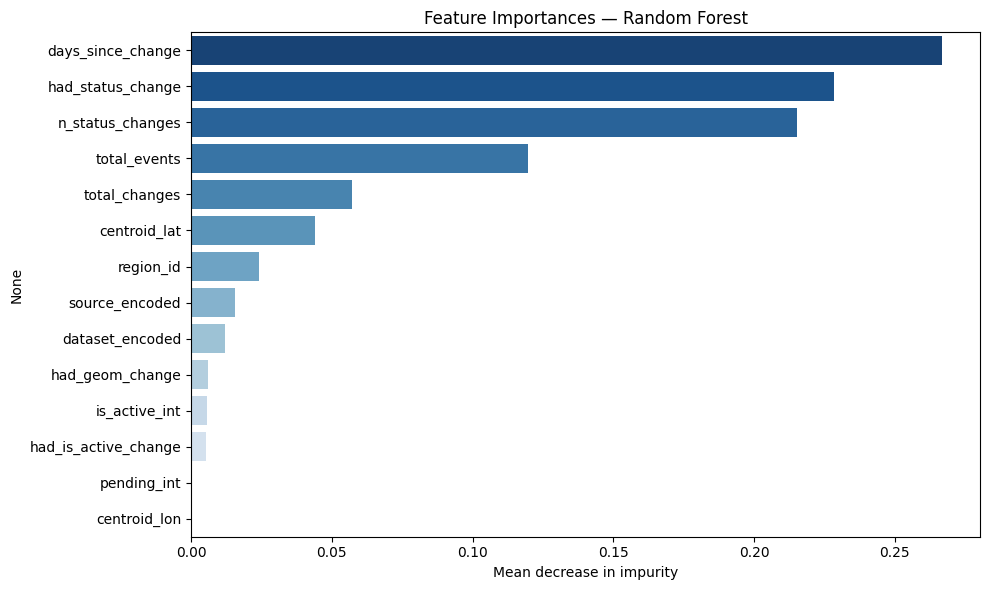


Top 5 features:
days_since_change    0.266938
had_status_change    0.228350
n_status_changes     0.215198
total_events         0.119533
total_changes        0.057165
dtype: float64


In [56]:
# --------------------------------------------
# Feature Importance Plot
# --------------------------------------------

importances = pd.Series(clf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Blues_r')
plt.title("Feature Importances — Random Forest")
plt.xlabel("Mean decrease in impurity")
plt.tight_layout()
plt.show()

print("\nTop 5 features:")
print(importances.head())

In [57]:
# --------------------------------------------
# Risk Score Every Zone
# --------------------------------------------

# Attach an escalation probability to every zone
zones_df['escalation_risk_score'] = clf.predict_proba(
    zones_df[feature_cols].fillna(0)
)[:, 1]

# --------------------------------------------
# Show zones NOT already under orders
# --------------------------------------------

# Exclude zones already at orders — we want to find what's ABOUT to escalate
not_yet_orders = zones_df[zones_df['status'] != 'orders'].copy()

top_risk = (
    not_yet_orders[['uid_v2', 'display_name', 'dataset_name',
                    'status', 'escalation_risk_score']]
    .sort_values('escalation_risk_score', ascending=False)
    .head(20)
)

print("TOP 20 HIGHEST RISK ZONES (excluding zones already at orders):")
print(top_risk.to_string(index=False))

# --------------------------------------------
# Show current warning zones ranked by risk
# --------------------------------------------

print("\nCURRENT WARNING ZONES RANKED BY ESCALATION RISK:")
warning_zones = (
    zones_df[zones_df['status'] == 'warnings'][
        ['uid_v2', 'display_name', 'dataset_name', 'escalation_risk_score']
    ]
    .sort_values('escalation_risk_score', ascending=False)
)
print(warning_zones.to_string(index=False))

# Save both outputs
top_risk.to_csv("top_risk_zones.csv", index=False)
warning_zones.to_csv("warning_zones_ranked.csv", index=False)
print("\nSaved to top_risk_zones.csv and warning_zones_ranked.csv")

TOP 20 HIGHEST RISK ZONES (excluding zones already at orders):
                                    uid_v2 display_name    dataset_name   status  escalation_risk_score
siskiyou-CA_US-SIS-1503-B-5ed7306d20088172   SIS-1503-B  siskiyou-CA_US warnings               0.666587
calaveras-CA_US-CCU-134-A-d36254716da1c704    CCU-134-A calaveras-CA_US warnings               0.652149
calaveras-CA_US-CCU-134-D-e8a3fc1f212cd13d    CCU-134-D calaveras-CA_US warnings               0.640913
        fresno-CA_US-K160-898b2c66cbefd828         K160    fresno-CA_US warnings               0.614613
         fresno-CA_US-K41-551a665541b92366          K41    fresno-CA_US warnings               0.612294
  siskiyou-CA_US-SIS-1301-450f7aca365cfcde     SIS-1301  siskiyou-CA_US warnings               0.546312
calaveras-CA_US-CCU-134-F-873579c49b501fc5    CCU-134-F calaveras-CA_US warnings               0.545249
  siskiyou-CA_US-SIS-1120-53e814f7d08e85b1     SIS-1120  siskiyou-CA_US     none               0.514088
 

In [61]:
# --------------------------------------------
# Add Risk Tier Labels and Recommended Actions
# --------------------------------------------

def risk_tier(score):
    if score >= 0.5:
        return 'HIGH'
    elif score >= 0.25:
        return 'MEDIUM'
    else:
        return 'LOW'

def recommended_action(tier):
    if tier == 'HIGH':
        return {
            'en': 'Immediate outreach required — notify residents to prepare for mandatory evacuation. Alert emergency services and pre-position resources.',
            'es': 'Se requiere divulgación inmediata — notificar a los residentes para que se preparen para la evacuación obligatoria. Alertar a los servicios de emergencia y preposicionar recursos.'
        }
    elif tier == 'MEDIUM':
        return {
            'en': 'Begin proactive outreach — send advisory updates and ensure vulnerable residents have transportation plans in place.',
            'es': 'Comenzar una divulgación proactiva — enviar actualizaciones de avisos y asegurar que los residentes vulnerables tengan planes de transporte establecidos.'
        }
    else:
        return {
            'en': 'Monitor closely — no immediate action required but flag for daily check-in during active fire season.',
            'es': 'Monitorear de cerca — no se requiere acción inmediata pero marcar para revisión diaria durante la temporada alta de incendios.'
        }

warning_zones['risk_tier'] = warning_zones['escalation_risk_score'].apply(risk_tier)
warning_zones['recommended_action'] = warning_zones['risk_tier'].apply(recommended_action)

print("WARNING ZONES BY RISK TIER:\n")
for _, row in warning_zones.iterrows():
    print(f"Zone: {row['display_name']}  ({row['dataset_name']})")
    print(f"Risk Score: {row['escalation_risk_score']:.4f}")
    print(f"Tier: {row['risk_tier']}")
    print(f"Action (EN): {row['recommended_action']['en']}")
    print(f"Action (ES): {row['recommended_action']['es']}")
    print("-" * 80)

warning_zones.to_csv("warning_zones_ranked.csv", index=False)
print("\nSaved to warning_zones_ranked.csv")

WARNING ZONES BY RISK TIER:

Zone: SIS-1503-B  (siskiyou-CA_US)
Risk Score: 0.6666
Tier: HIGH
Action (EN): Immediate outreach required — notify residents to prepare for mandatory evacuation. Alert emergency services and pre-position resources.
Action (ES): Se requiere divulgación inmediata — notificar a los residentes para que se preparen para la evacuación obligatoria. Alertar a los servicios de emergencia y preposicionar recursos.
--------------------------------------------------------------------------------
Zone: CCU-134-A  (calaveras-CA_US)
Risk Score: 0.6521
Tier: HIGH
Action (EN): Immediate outreach required — notify residents to prepare for mandatory evacuation. Alert emergency services and pre-position resources.
Action (ES): Se requiere divulgación inmediata — notificar a los residentes para que se preparen para la evacuación obligatoria. Alertar a los servicios de emergencia y preposicionar recursos.
--------------------------------------------------------------------------

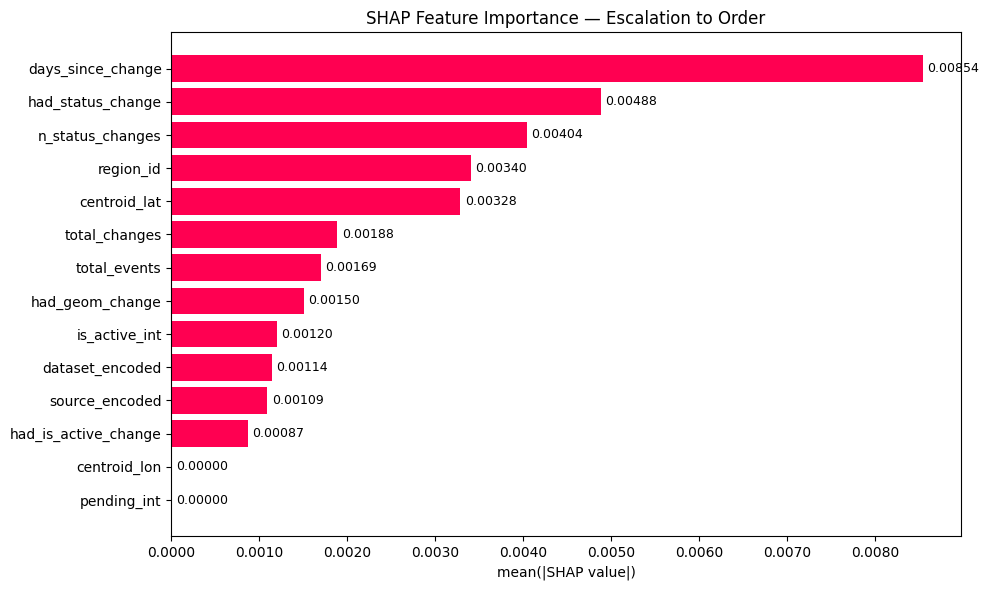

In [64]:
# --------------------------------------------
# SHAP Bar Chart
# --------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# Calculate mean absolute SHAP values per feature
shap_vals = shap_values[:, :, 1].values
mean_shap = np.abs(shap_vals).mean(axis=0)

# Put into a dataframe and sort
shap_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': mean_shap
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(shap_df['feature'], shap_df['importance'], color='#ff0051')

# Add proper decimal labels on each bar
for bar, val in zip(bars, shap_df['importance']):
    ax.text(
        bar.get_width() + 0.00005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.5f}',
        va='center',
        fontsize=9
    )

ax.set_xlabel('mean(|SHAP value|)')
ax.set_title('SHAP Feature Importance — Escalation to Order')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))
plt.tight_layout()
plt.show()